<a href="https://colab.research.google.com/github/ShafaAzahri/Pengolahan-Citra-2C/blob/main/Jobsheet%205%20%3A%20%20MENGUKUR%20KEMIRIPAN%20CITRA%20DAN%20PENERAPANNYA%20DALAM%20PENGENALAN%20POLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


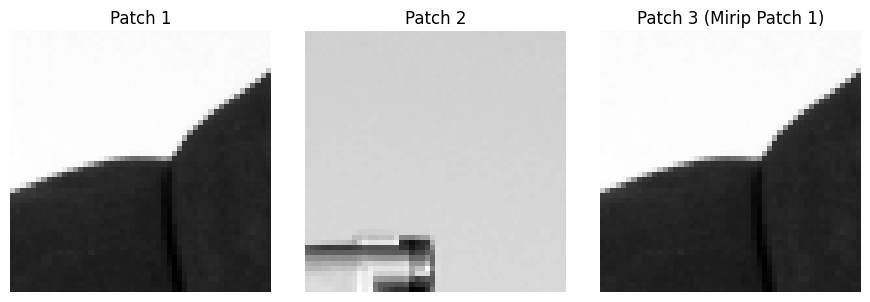

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt
# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] # Patch dari lokasi berbeda
patch3 = patch1 + 0.1 # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1) # Pastikan nilai tetap di [0, 1]
# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()
# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)
# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)
# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()


#Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity Astronaut vs Coffee: 0.8156
Cosine Similarity Astronaut vs Astronaut: 1.0000
Cosine Similarity Astronaut vs Downsampled: 1.0000


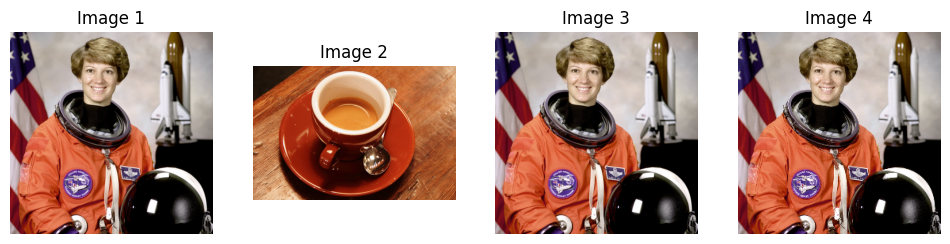

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_combined /= np.sum(hist_combined)
    return hist_combined

image1 = data.astronaut()
image2 = data.coffee()
image3 = data.astronaut()
image4 = image1[::2, ::2, :]

hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

print(f"Cosine Similarity Astronaut vs Coffee: {sim_12:.4f}")
print(f"Cosine Similarity Astronaut vs Astronaut: {sim_13:.4f}")
print(f"Cosine Similarity Astronaut vs Downsampled: {sim_14:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4'); axes[3].axis('off')
plt.show()


#Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM Same: 1.0000
SSIM Noisy: 0.2943
SSIM Contrast: 0.9651
SSIM Blurred: 0.8027


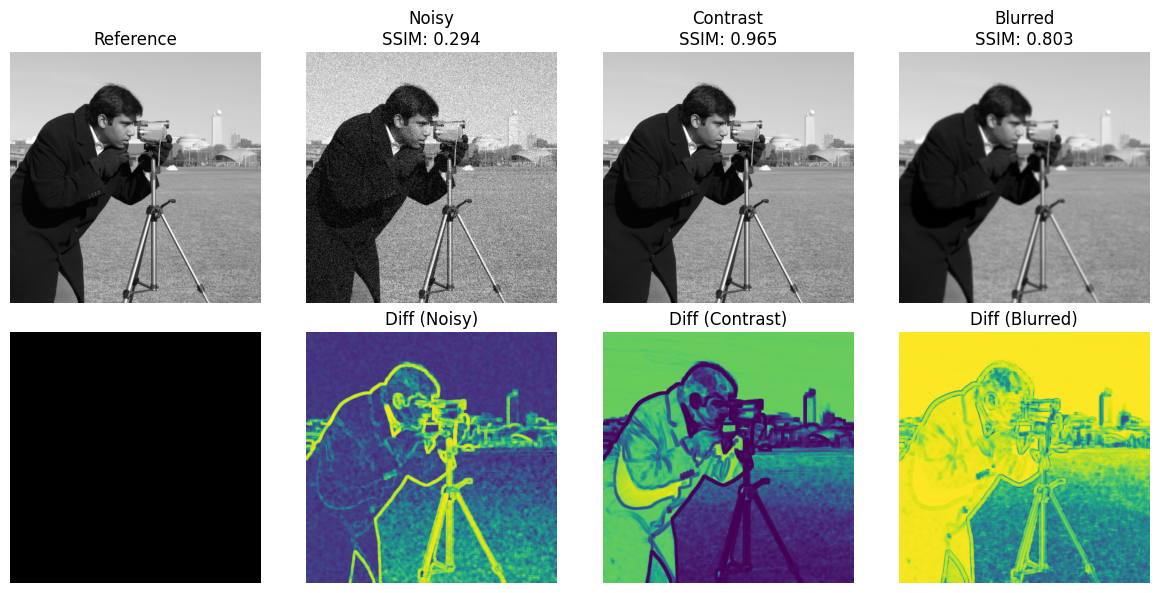

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.filters import gaussian
from skimage.util import random_noise

image_ref = img_as_float(data.camera())
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5)

data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

print(f"SSIM Same: {ssim_same:.4f}")
print(f"SSIM Noisy: {ssim_noisy:.4f}")
print(f"SSIM Contrast: {ssim_contrast:.4f}")
print(f"SSIM Blurred: {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
axes[0].imshow(image_ref, cmap='gray'); axes[0].set_title('Reference'); axes[0].axis('off')
axes[1].imshow(image_noisy, cmap='gray'); axes[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}'); axes[1].axis('off')
axes[2].imshow(image_contrast, cmap='gray'); axes[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); axes[2].axis('off')
axes[3].imshow(image_blurred, cmap='gray'); axes[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); axes[3].axis('off')
axes[4].imshow(np.zeros_like(image_ref), cmap='gray'); axes[4].axis('off')
axes[5].imshow(diff_noisy, cmap='viridis'); axes[5].set_title('Diff (Noisy)'); axes[5].axis('off')
axes[6].imshow(diff_contrast, cmap='viridis'); axes[6].set_title('Diff (Contrast)'); axes[6].axis('off')
axes[7].imshow(diff_blurred, cmap='viridis'); axes[7].set_title('Diff (Blurred)'); axes[7].axis('off')
plt.tight_layout()
plt.show()


#Praktikum 4. Penerapan Template Matching

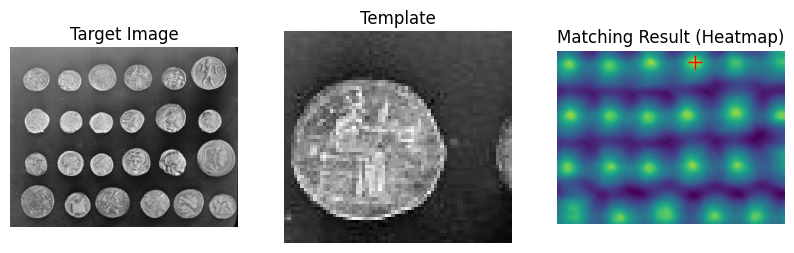

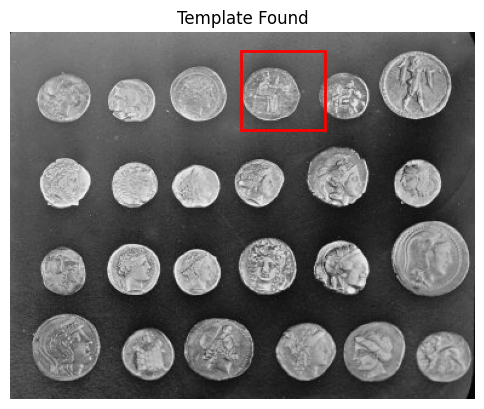

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()
template = image[15:80, 190:260]  # Ambil salah satu koin sebagai template

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()
ax[2].plot(x, y, 'r+', markersize=10)  # Tandai lokasi terbaik pada heatmap

fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()


# Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana

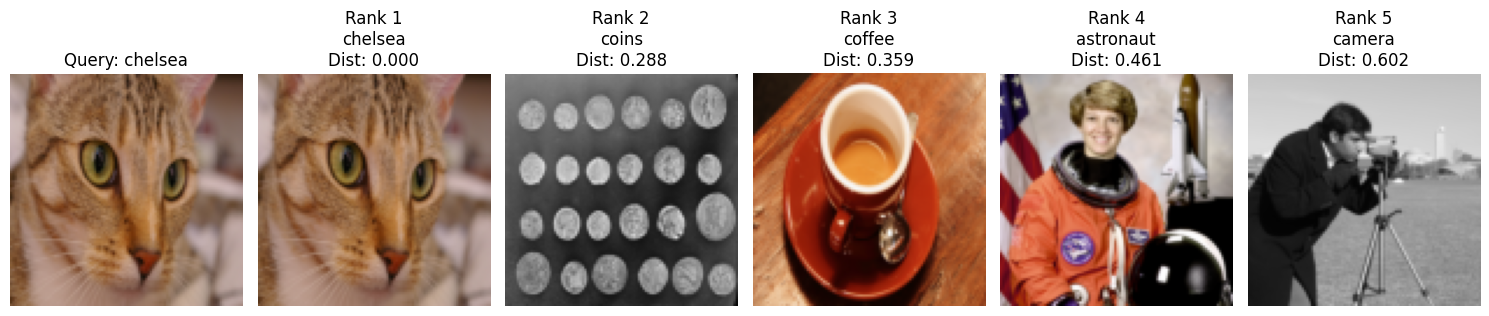

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    from skimage import img_as_ubyte
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_combined /= hist_combined.sum() if hist_combined.sum() != 0 else 1
    return hist_combined

image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
    database_images.append(img_resized)
    database_hists.append(calculate_rgb_histogram(img_resized))

query_index = image_db_names.index("chelsea")
query_image = database_images[query_index]
query_hist = database_hists[query_index]
t66666
distances = [distance.cosine(query_hist, hist) for hist in database_hists]
sorted_indices = np.argsort(distances)

fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))
axes[0].imshow(query_image); axes[0].set_title("Query: chelsea"); axes[0].axis('off')

for i, idx in enumerate(sorted_indices):
    ax = axes[i+1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')

plt.tight_layout()
plt.show()


#Penugasan 3

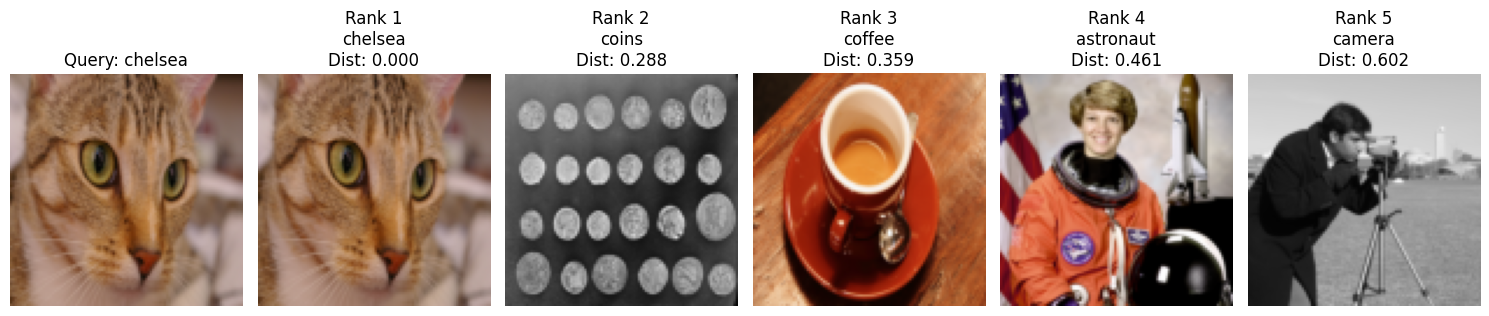

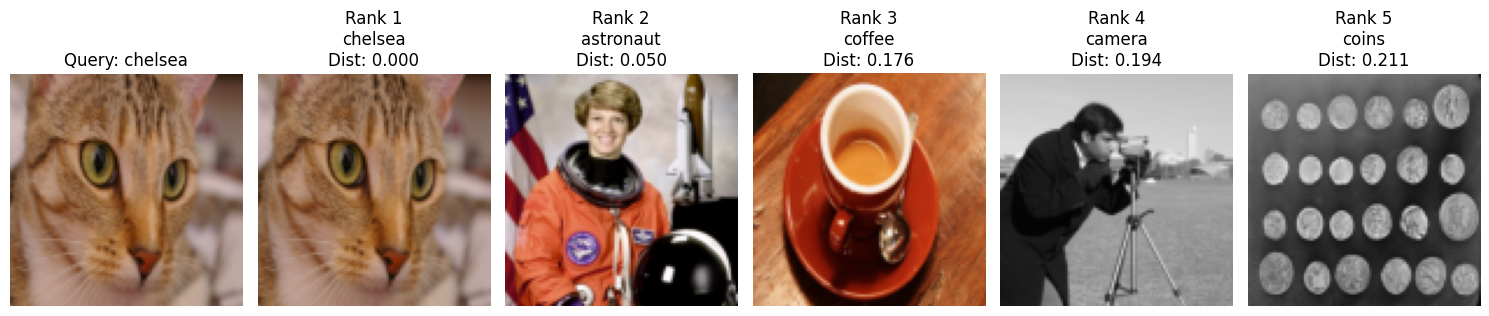

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, color, transform, img_as_float
from scipy.spatial import distance

# Fungsi untuk menghitung rata-rata warna (mean R, mean G, mean B)
def calculate_mean_color(image):
    mean_r = np.mean(image[:,:,0])  # Rata-rata nilai R
    mean_g = np.mean(image[:,:,1])  # Rata-rata nilai G
    mean_b = np.mean(image[:,:,2])  # Rata-rata nilai B
    return np.array([mean_r, mean_g, mean_b])  # Kembalikan sebagai vektor fitur 3 dimensi

# Fungsi hitung histogram dari Praktikum 2
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    return hist_combined

# 1. Siapkan 'database' citra kecil dan citra query
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []
database_mean_colors = []

for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:  # Jika grayscale, konversi ke RGB
        img = color.gray2rgb(img)
    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
    database_images.append(img_resized)
    database_hists.append(calculate_rgb_histogram(img_resized))
    database_mean_colors.append(calculate_mean_color(img_resized))

# 2. Hitung jarak/kemiripan antara query dan semua citra di database menggunakan rata-rata warna
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]
query_mean_color = database_mean_colors[query_index]

distances_hist = []
distances_mean_color = []

for i, (hist, mean_color) in enumerate(zip(database_hists, database_mean_colors)):
    dist_hist = distance.cosine(query_hist, hist)  # Menggunakan histogram
    dist_mean_color = distance.euclidean(query_mean_color, mean_color)  # Menggunakan rata-rata warna
    distances_hist.append(dist_hist)
    distances_mean_color.append(dist_mean_color)

# 3. Urutkan citra berdasarkan jarak (dari terkecil ke terbesar)
sorted_indices_hist = np.argsort(distances_hist)
sorted_indices_mean_color = np.argsort(distances_mean_color)

# 4. Tampilkan hasil: Query dan citra terurut berdasarkan kemiripan
fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))

axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

for i, idx in enumerate(sorted_indices_hist):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances_hist[idx]:.3f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Menampilkan hasil retrieval menggunakan rata-rata warna
fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))

axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

for i, idx in enumerate(sorted_indices_mean_color):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances_mean_color[idx]:.3f}")
    ax.axis('off')

plt.tight_layout()
plt.show()


#Penugasan 4

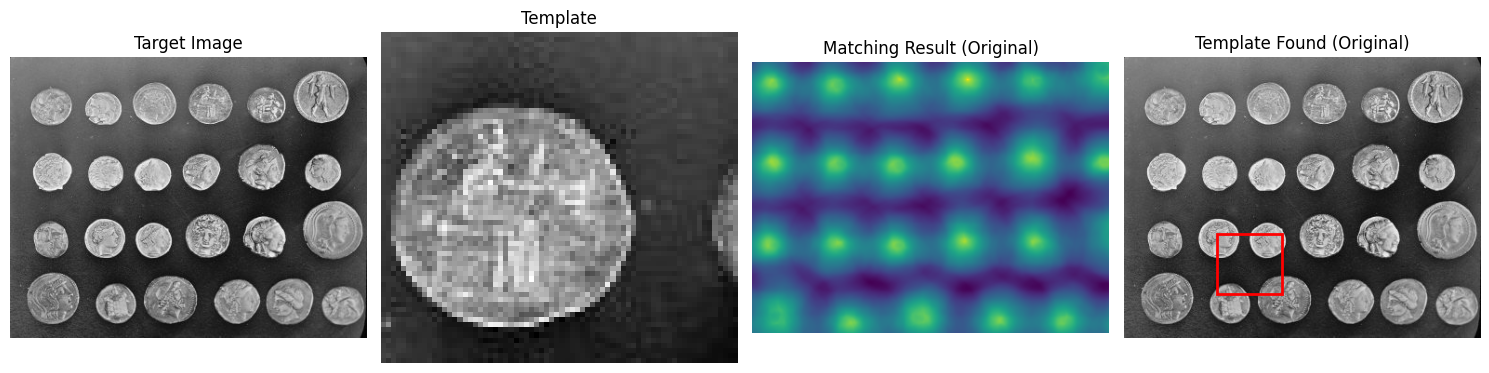

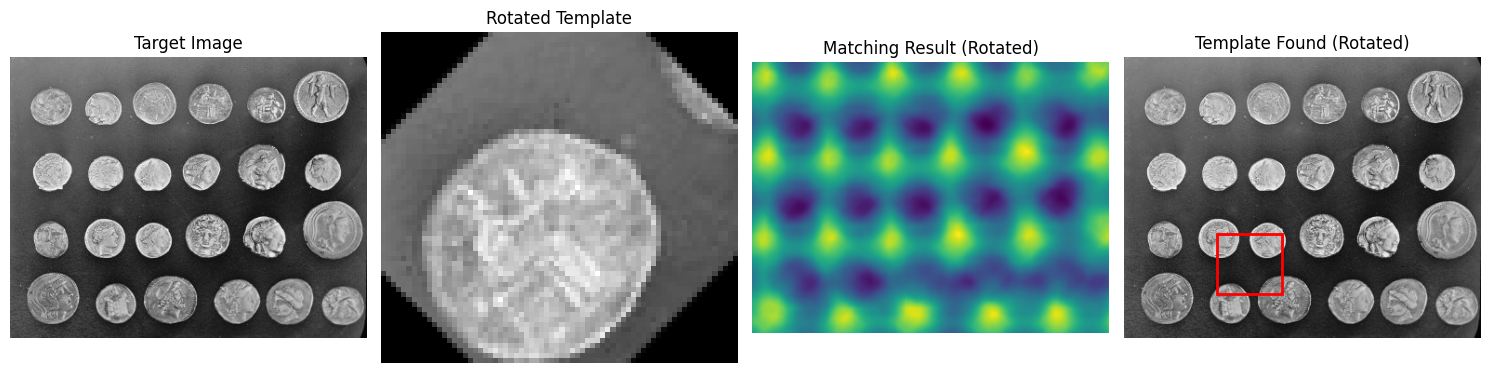

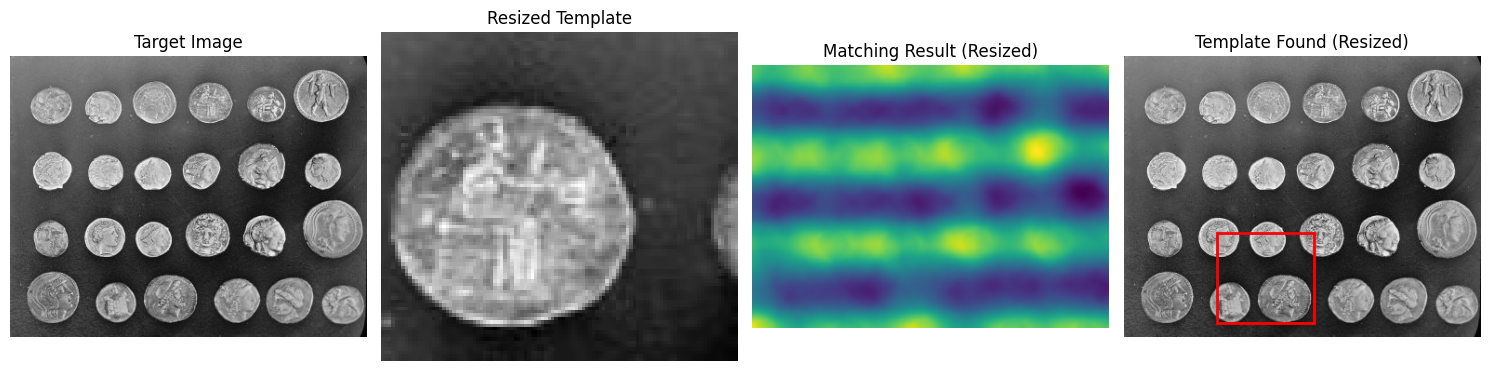

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, resize

# Muat citra target dan buat/muat citra template
image = data.coins()
template = image[15:80, 190:260]  # Ambil salah satu koin sebagai template

# Lakukan template matching dengan template asli
result = match_template(image, template)

# Coba rotasi template
template_rotated = rotate(template, 45)  # Rotasi template 45 derajat
result_rotated = match_template(image, template_rotated)

# Coba ubah ukuran template
template_resized = resize(template, (int(template.shape[0] * 1.5), int(template.shape[1] * 1.5)))  # Ubah ukuran template
result_resized = match_template(image, template_resized)

# Visualisasi hasilnya
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Target Image
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Target Image')
axes[0].axis('off')

# Template
axes[1].imshow(template, cmap='gray')
axes[1].set_title('Template')
axes[1].axis('off')

# Matching Result
axes[2].imshow(result, cmap='viridis')
axes[2].set_title('Matching Result (Original)')
axes[2].axis('off')

# Template Found in Target Image (Original)
axes[3].imshow(image, cmap='gray')
axes[3].set_title('Template Found (Original)')
axes[3].axis('off')
h, w = template.shape
rect = plt.Rectangle((100, 190), w, h, edgecolor='r', facecolor='none', lw=2)
axes[3].add_patch(rect)

plt.tight_layout()
plt.show()

# Visualisasi hasil pencocokan dengan template yang dirotasi dan diubah ukurannya
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Target Image
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Target Image')
axes[0].axis('off')

# Rotated Template
axes[1].imshow(template_rotated, cmap='gray')
axes[1].set_title('Rotated Template')
axes[1].axis('off')

# Rotated Matching Result
axes[2].imshow(result_rotated, cmap='viridis')
axes[2].set_title('Matching Result (Rotated)')
axes[2].axis('off')

# Template Found in Target Image (Rotated)
axes[3].imshow(image, cmap='gray')
axes[3].set_title('Template Found (Rotated)')
axes[3].axis('off')
h, w = template_rotated.shape
rect = plt.Rectangle((100, 190), w, h, edgecolor='r', facecolor='none', lw=2)
axes[3].add_patch(rect)

plt.tight_layout()
plt.show()

# Visualisasi hasil pencocokan dengan template yang diubah ukurannya
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Target Image
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Target Image')
axes[0].axis('off')

# Resized Template
axes[1].imshow(template_resized, cmap='gray')
axes[1].set_title('Resized Template')
axes[1].axis('off')

# Resized Matching Result
axes[2].imshow(result_resized, cmap='viridis')
axes[2].set_title('Matching Result (Resized)')
axes[2].axis('off')

# Template Found in Target Image (Resized)
axes[3].imshow(image, cmap='gray')
axes[3].set_title('Template Found (Resized)')
axes[3].axis('off')
h, w = template_resized.shape
rect = plt.Rectangle((100, 190), w, h, edgecolor='r', facecolor='none', lw=2)
axes[3].add_patch(rect)

plt.tight_layout()
plt.show()
